In [1]:
import pandas as pd
import numpy as np
import polars as pl
from scipy import stats
import glob
import os
import re
import seaborn as sns
import matplotlib 
from matplotlib import pyplot as plt
from statsmodels.stats.multitest import multipletests
from scipy.stats import pearsonr, spearmanr
import statsmodels
from plotnine import *
import upsetplot
import pysam
#import utils
from upsetplot import from_indicators, UpSet

matplotlib.rcParams["pdf.fonttype"] = 42  # Use TrueType fonts instead of Type 3 fonts
matplotlib.rcParams["ps.fonttype"] = 42  # For PostScript as well, if needed

%matplotlib inline

analysis_dir = "/staging/leuven/stg_00090/ASA/analysis/"
outdir = "/staging/leuven/stg_00090/ASA/analysis/Manuscript/Figures"

os.makedirs(f"{outdir}/main", exist_ok=True)
os.makedirs(f"{outdir}/suppl", exist_ok=True)

# colormap_cell_types = {
#     'L5_ET': '#f7b6d2', 
#     'L56_NP': '#e377c2', 
#     'L6_CT': '#98df8a', 
#     'L6_IT_Car3': '#ff9896',
#     'L6_IT': '#9467bd', 
#     'L6b': '#7f7f7f', 
#     'L23_IT': '#17becf', 
#     'Pvalb': 'dodgerblue', 
#     'Sst': '#ffbb78',
#     'L5_IT':'#ff6347',
#     'L5_IT_A': '#c49c94',
#     'L5_IT_B': 'black',
#     'L4_IT': '#f7b6d2', 
#     'Vip': '#dbdb8d', 
#     'Lamp5': '#9edae5', 
#     'Sncg': '#8e44ad', 
#     'VLMC':'#e6e6fa',
#     'Sst_put':'bisque',
#     'Oligo':'#1f77b4',
#     'Astro':'#ff7f0e',
#     'Micro-PVM':'#2ca02c',
#     'OPC':'#d62728',
#     'immune':'palegreen',
#     'Endo':'saddlebrown',
#     'GlutaN':'blueviolet',
#     'Oligo':'#1f77b4',
#     'Astro':'#ff7f0e',
#     'Micro-PVM':'#2ca02c',
#     'OPC':'#d62728',
#     'GabaN': 'violet',
#     'DopaN':'darkgoldenrod',
#     'GlutaN':'blueviolet',
#     'immune':'palegreen',
#     'Endo':'saddlebrown'
# }

col25 = [
    "#FF0000",  # Red
    "#00FF00",  # Green
    "#0000FF",  # Blue
    "#FFFF00",  # Yellow
    "#FF00FF",  # Magenta
    "#00FFFF",  # Cyan
    "#800000",  # Maroon
    "#808000",  # Olive
    "#008080",  # Teal
    "#800080",  # Purple
    "#FFA500",  # Orange
    "#A52A2A",  # Brown
    "#D2691E",  # Chocolate
    "#2E8B57",  # Sea Green
    "#4682B4",  # Steel Blue
    "#8A2BE2",  # Blue Violet
    "#DC143C",  # Crimson
    "#DAA520",  # Goldenrod
    "#5F9EA0",  # Cadet Blue
    "#FF4500",  # Orange Red
    "#ADFF2F",  # Green Yellow
    "#32CD32",  # Lime Green
    "#1E90FF",  # Dodger Blue
    "#FF1493",  # Deep Pink
    "#9400D3"   # Dark Violet
]


cell_type_labels_corr={"L23_IT": "L2/3 IT","L5_IT": "L5 IT", "L6_CT": "L6 CT", "L4_IT": "L4 IT", "L5_IT_A": "L5 IT A", "L5_IT_B": "L5 IT B", "L6_IT": "L6 IT", "L6_IT_Car3": "L6 IT Car3", "L56_NP": "L5/6 NP"}


# VCF with genotypes
vcf_path = "/staging/leuven/stg_00090/ASA/analysis/2024_T2T_ATAC_analysis/20250107_allelic_analysis/WGS_chm13_BCFs.missing_to_ref.norm.subset_peaks_exended2500bp.vcf.gz"
vcf = pysam.VariantFile(vcf_path)

# donor info
donors_path = '/lustre1/project/stg_00090/ASA//analysis/donor_statistics/crn_metadata/SUBJECT.csv'
df_donors = pd.read_csv(donors_path) # some mismatch in fields, not loaded by polars correctly - to check
df_donors = pl.from_pandas(df_donors[["subject_id", "primary_diagnosis", "age_at_collection", "age_at_diagnosis"]])



ModuleNotFoundError: No module named 'upsetplot'

In [3]:
def get_coherence(df_sel,  x_var = "slope", y_var = "allelic_imbalance", print_res = True):

    N = df_sel.shape[0]
    n_var = df_sel.variant_id.nunique()
    n_coherent = np.sum(np.sign(df_sel[y_var]) == np.sign(df_sel[x_var]))
    share_coherent = round(n_coherent / N, 3)
    cor = round(pearsonr(df_sel[x_var], df_sel[y_var])[0], 2)

    if print_res:
        print(f"Total number of tests: {N}")
        print(f"Number of unique variants: {n_var}")
        print(f"Number of coherent variants: {n_coherent} ({share_coherent*100}%)")
        print(f"Pearson correlation: {cor}")
    
    perf_dict = {"N_obs": N, "N_var": n_var, "n_coherent": n_coherent, "share_coherent": share_coherent, "cor": cor}
    return perf_dict


def plot_power_heatmap(tmp, var1 = 'fdr_thres_asca', var2 = 'fdr_thres_qtl', val = 'share_coherent',
                       lab1 = "FDR threshold, ASCA", lab2 = "FDR threshold, caQTL",
                       title = 'Share of coherent SNPs by ISM delta and Allelic imbalance\n(Number of SNPs)'):

    tmp["n_obs_formatted"] = ["{:,}".format(x) for x in tmp.n_obs.tolist()]
    tmp["n_var_formatted"] = ["{:,}".format(x) for x in tmp.n_variants.tolist()]

    # Pivot the DataFrame to have rows and columns
    pivot_df = tmp.pivot(index=var1, columns=var2, values=val)

    # Create a DataFrame for annotations
    annot_df = tmp.pivot(index=var1, columns=var2, values=val).astype(str) + '\n(' + \
                tmp.pivot(index=var1, columns=var2, values='n_obs_formatted').astype(str) + " obs," +  "\n" + \
                tmp.pivot(index=var1, columns=var2, values='n_var_formatted').astype(str) + " var)"

    # Create the heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(pivot_df, annot=annot_df, fmt="", cmap="YlGnBu", cbar=False, vmax=1)

    # Set labels and title
    plt.ylabel(lab1)
    plt.xlabel(lab2)
    plt.title(title)

    # Show the plot
    #plt.show()
    return plt


In [4]:
colormap_asap_path = "/staging/leuven/stg_00090/ASA/analysis/20221129_mo_RNA_annotation_AP/colormap_asap.txt"

with open(colormap_asap_path, "r", encoding="utf-8") as f:
    lines = f.read().splitlines()  # drops trailing newline chars

# remove empty/whitespace-only lines at the end
while lines and not lines[-1].strip():
    lines.pop()

colormap_cell_types = {}
for line in lines[1:]:  # skip header
    celltype, color = line.split("\t", 1)
    colormap_cell_types[celltype] = color.strip()

colormap_cell_types


{'L2/3 IT': '#ff0000',
 'doublet': '#ffc480',
 'Oligo': '#149900',
 'Astro': '#8f00b3',
 'OPC': '#2EF0F0',
 'Micro-PVM': '#bf9360',
 'L5 IT': '#B2F7B7',
 'Vip': '#79baf2',
 'Pvalb': '#FA9A6E',
 'Sst': '#990000',
 'L6 IT': '#F7A400',
 'L2/3_suspicious': '#283326',
 'Lamp5': '#2d4459',
 'L4 IT': '#307cbf',
 'L6 CT': '#4c0000',
 'Sncg': '#FA7ADC',
 'L6b': '#00f220',
 'L5/6 NP': '#accbe6',
 'L5 ET': '#520066',
 'L6 IT Car3': '#330000',
 'VLMC': '#594f43',
 'Endo': '#16591f',
 'Sst Chodl': '#00FF00',
 'neuron': '#FF0000',
 'DopaN': '#0096FF',
 'neuron_GLUL+': '#e59900',
 'GabaN': '#ace6b4',
 'OLG/OPC': '#262d33',
 'neuron_unk': '#ee00ff',
 'GlutaN': '#e57373',
 'unk': '#8c5e00',
 '': '#7f7340'}

# Load data

In [5]:
data_dir = "/staging/leuven/stg_00090/ASA/analysis/Manuscript/Tables/"
qtl_asca = pl.read_csv(f"{data_dir}/caQTL_ASCA_ISM_combined.csv.gz")

qtl_asca = qtl_asca.with_columns(
    pl.col("cell_type").replace(cell_type_labels_corr).alias("cell_type_corrected")
)

qtl_asca["variant_id"].n_unique()

2234291

In [6]:
qtl_asca_filt = qtl_asca.filter(pl.col("signif_caQTL_ASCA_no_effect_size_filter"))
var_list = qtl_asca_filt["variant_id"].unique().to_list()

# Correlation and concordance of caQTL and ASCA with different thresholds

In [6]:
qtl_asca.columns

['variant_id',
 'variant_type',
 'peak_id',
 'brain_region',
 'cell_type',
 'diff',
 'logfc',
 'max_percentile',
 'model',
 'start_distance',
 'end_distance',
 'af',
 'ma_samples',
 'ma_count',
 'pval_nominal',
 'slope',
 'slope_se',
 'chr',
 'caQTL_pval_adj_full',
 'TEST.SNP.CHROM',
 'TEST.SNP.POS',
 'TEST.SNP.REF.ALLELE',
 'TEST.SNP.ALT.ALLELE',
 'REGION.START',
 'REGION.END',
 'LOGLIKE.NULL',
 'LOGLIKE.ALT',
 'CHISQ',
 'P.VALUE',
 'ALPHA',
 'BETA',
 'PHI',
 'TOTAL.AS.READ.COUNT',
 'REF.AS.READ.COUNT',
 'ALT.AS.READ.COUNT',
 'TOTAL.READ.COUNT',
 'REF_LEN',
 'ALT_LEN',
 'allelic_imbalance',
 'MAX_ALLELE_LEN',
 'pval_adj',
 'signif_fdr05',
 'indel_bin',
 'signif',
 'pval_adj_full',
 'signif_fdr05_full',
 'ASCA_pval_adj_full',
 'asca_fdr_bin',
 'qtl_fdr_bin',
 'abs_allelic_imbalance',
 'abs_slope',
 'allelic_imbalance_0.1',
 'slope_0.1',
 'effect_size_filt',
 'signif_ASCA',
 'signif_caQTL',
 'signif_caQTL_ASCA',
 'signif_caQTL_or_ASCA',
 'signif_caQTL_or_ASCA_fdr001',
 'signif_caQTL_ASC

In [9]:
fdr_thres = [0.01, 0.05, 0.1, 0.3, 0.5, 0.9, 1]
df_coherence = pd.DataFrame(columns=['variant_type', 'fdr_thres_asca', 'fdr_thres_qtl', "n_obs", 
                                     'n_variants', 'correlation', 'share_coherent', 'n_coherent'])
var_types = ["SNP", "Indel"]


for fdr_qtl in fdr_thres:
    for fdr_asca in list(reversed(fdr_thres)):

        df_sel = qtl_asca.filter(pl.col("caQTL_pval_adj_full") < fdr_qtl,
                                 pl.col("ASCA_pval_adj_full") < fdr_asca)
        
        if df_sel.shape[0] > 0:

            # get coherence discionary
            cd = get_coherence(df_sel.to_pandas(), print_res = False)

            # add to dataframe
            df_coherence.loc[len(df_coherence)] = {"variant_type": "all", "fdr_thres_asca": fdr_asca, "fdr_thres_qtl": fdr_qtl, 
                                                "n_obs": cd["N_obs"], "n_variants": cd["N_var"], "correlation": cd["cor"], 
                                                "share_coherent": cd["share_coherent"], "n_coherent": cd["n_coherent"]}
            
            # now the same for SNPs and Indels
            for var_type in var_types:
                df_sel_var = df_sel.filter(pl.col("variant_type") == var_type)
                if df_sel_var.shape[0] > 0:
                    cd = get_coherence(df_sel_var.to_pandas(), print_res = False)
                    df_coherence.loc[len(df_coherence)] = {"variant_type": var_type, "fdr_thres_asca": fdr_asca, "fdr_thres_qtl": fdr_qtl, 
                                                        "n_obs": cd["N_obs"], "n_variants": cd["N_var"], "correlation": cd["cor"], 
                                                        "share_coherent": cd["share_coherent"], "n_coherent": cd["n_coherent"]}





all
Coherence between caQTL and Allelic imbalance


/tmp/ipykernel_3260087/89555231.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3260087/89555231.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


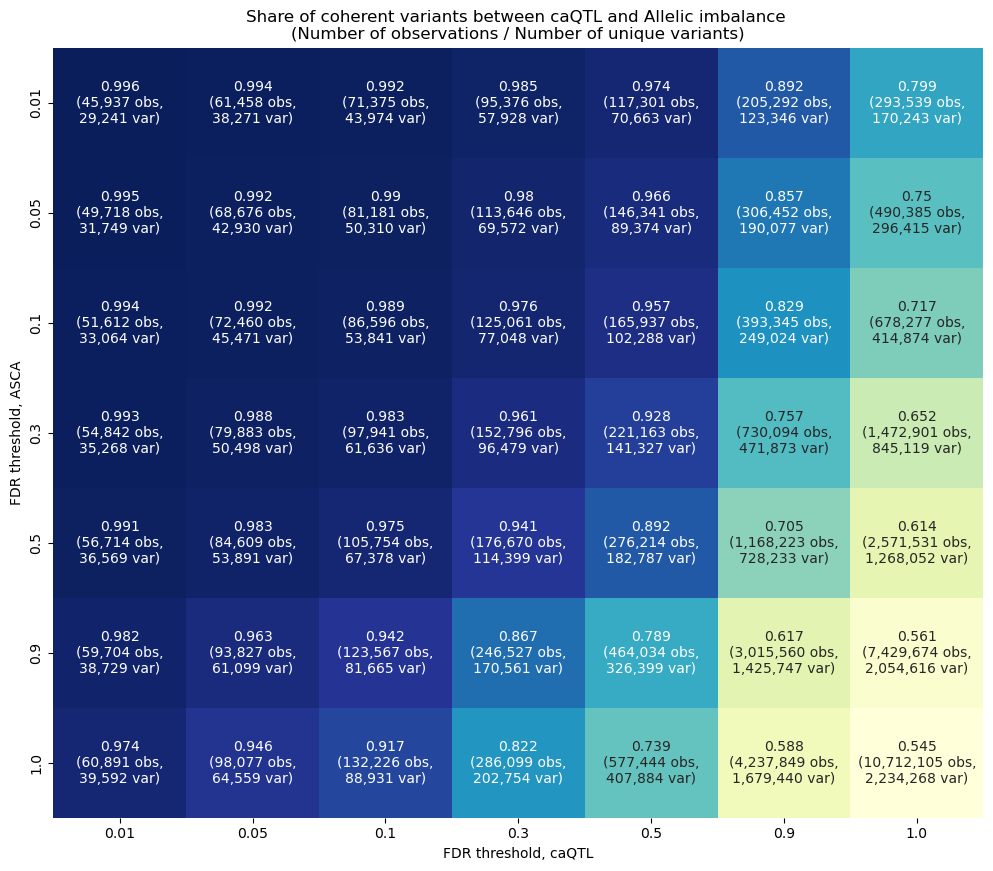

Correlation between caQTL and Allelic imbalance




/tmp/ipykernel_3260087/89555231.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3260087/89555231.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


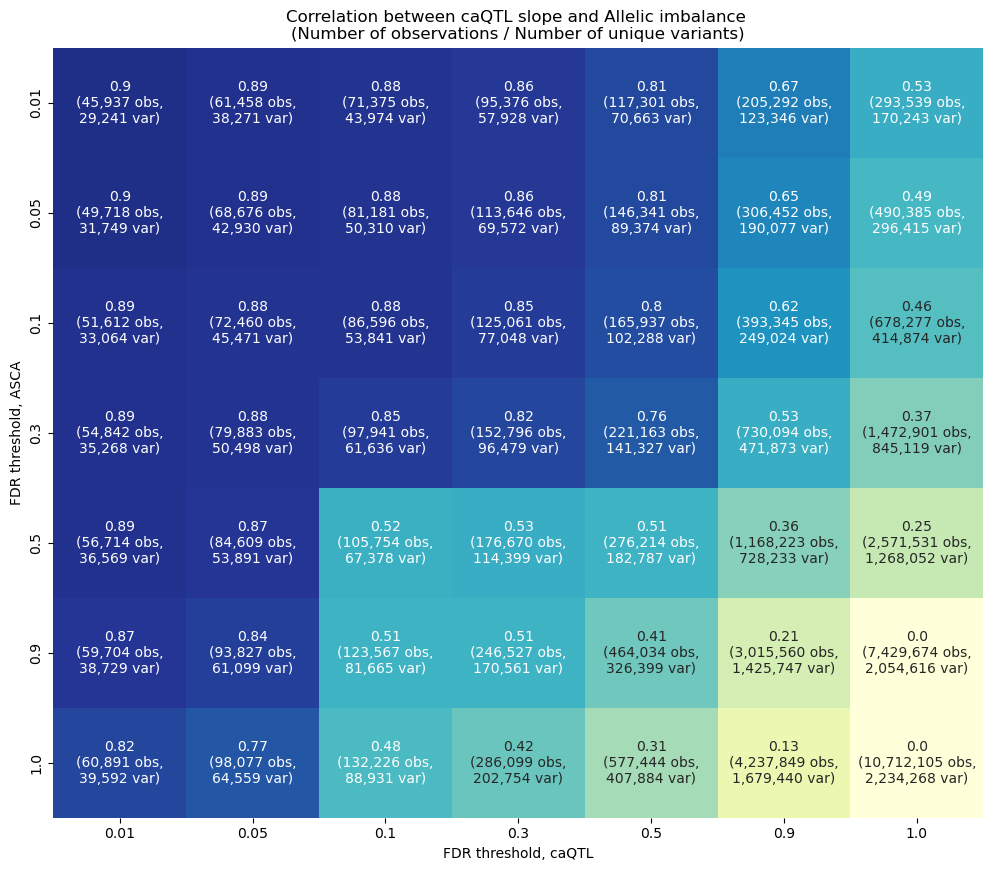

SNP
Coherence between caQTL and Allelic imbalance


/tmp/ipykernel_3260087/89555231.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3260087/89555231.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


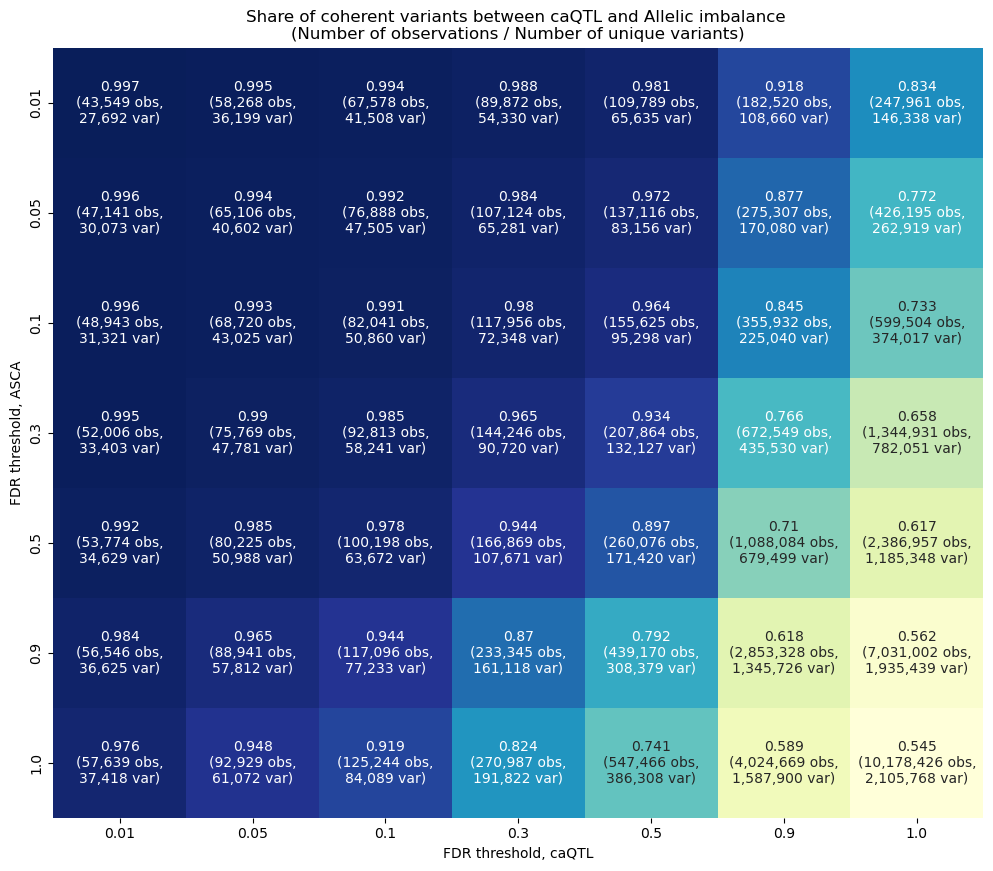

Correlation between caQTL and Allelic imbalance




/tmp/ipykernel_3260087/89555231.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3260087/89555231.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


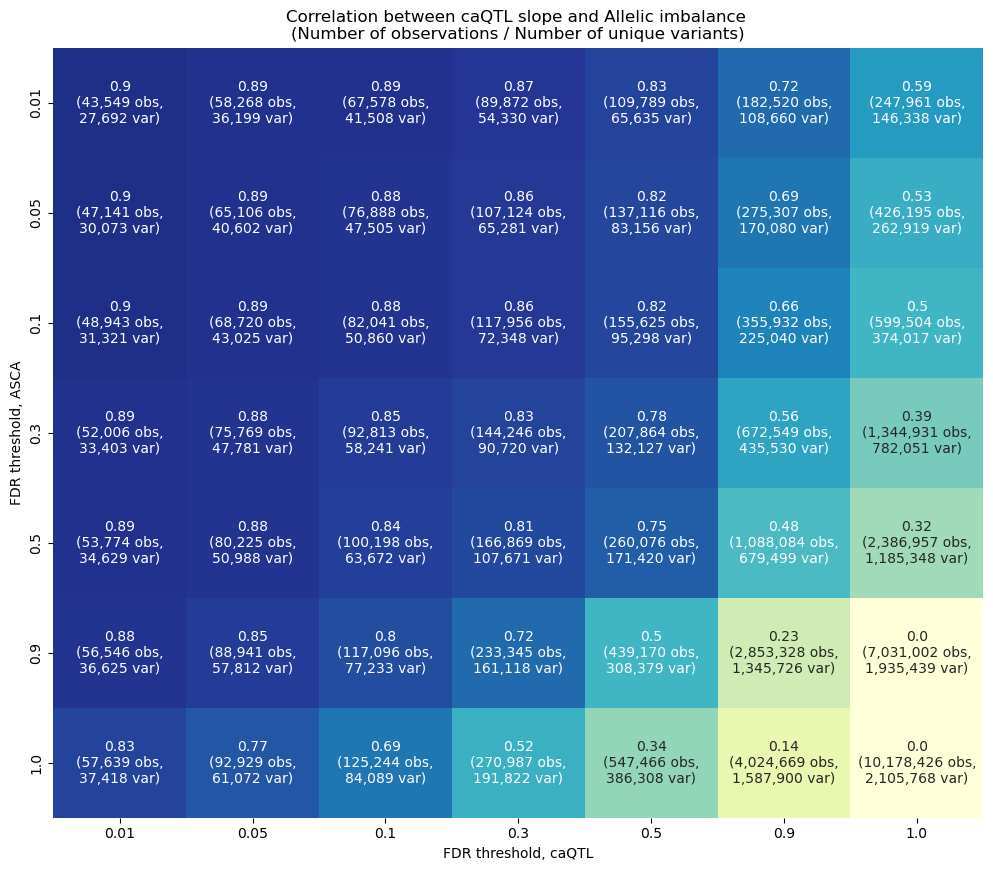

Indel
Coherence between caQTL and Allelic imbalance


/tmp/ipykernel_3260087/89555231.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3260087/89555231.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


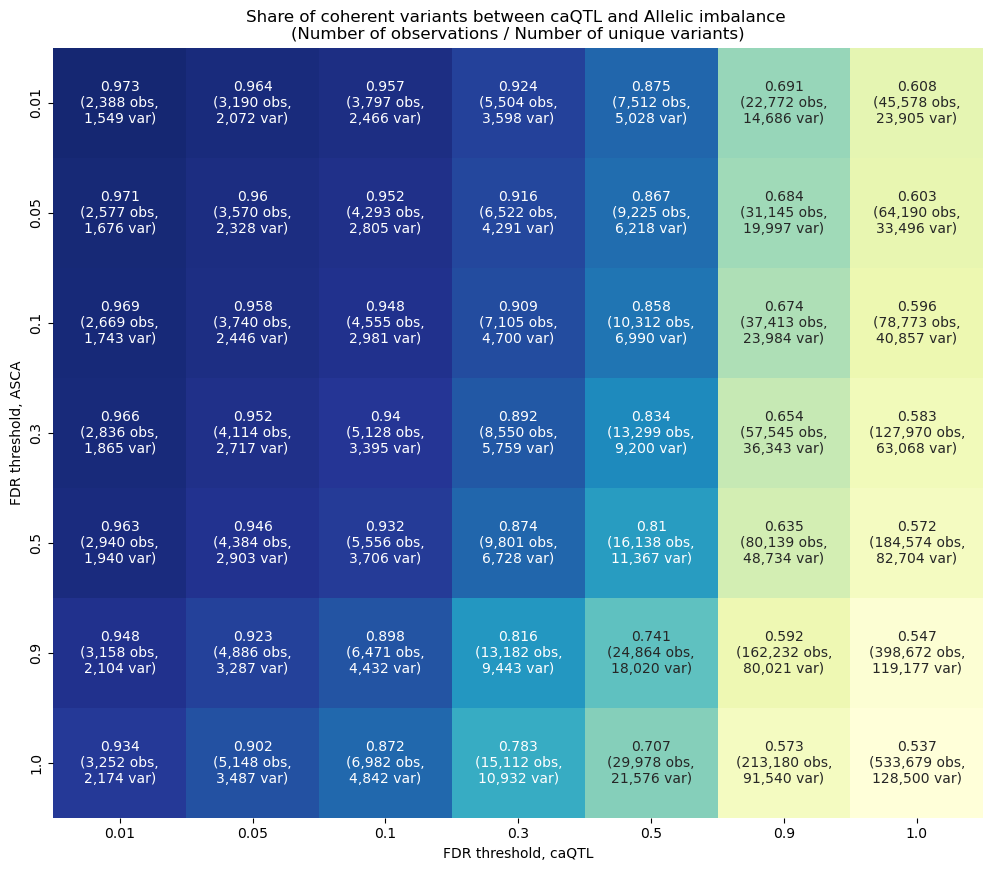

Correlation between caQTL and Allelic imbalance




/tmp/ipykernel_3260087/89555231.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3260087/89555231.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


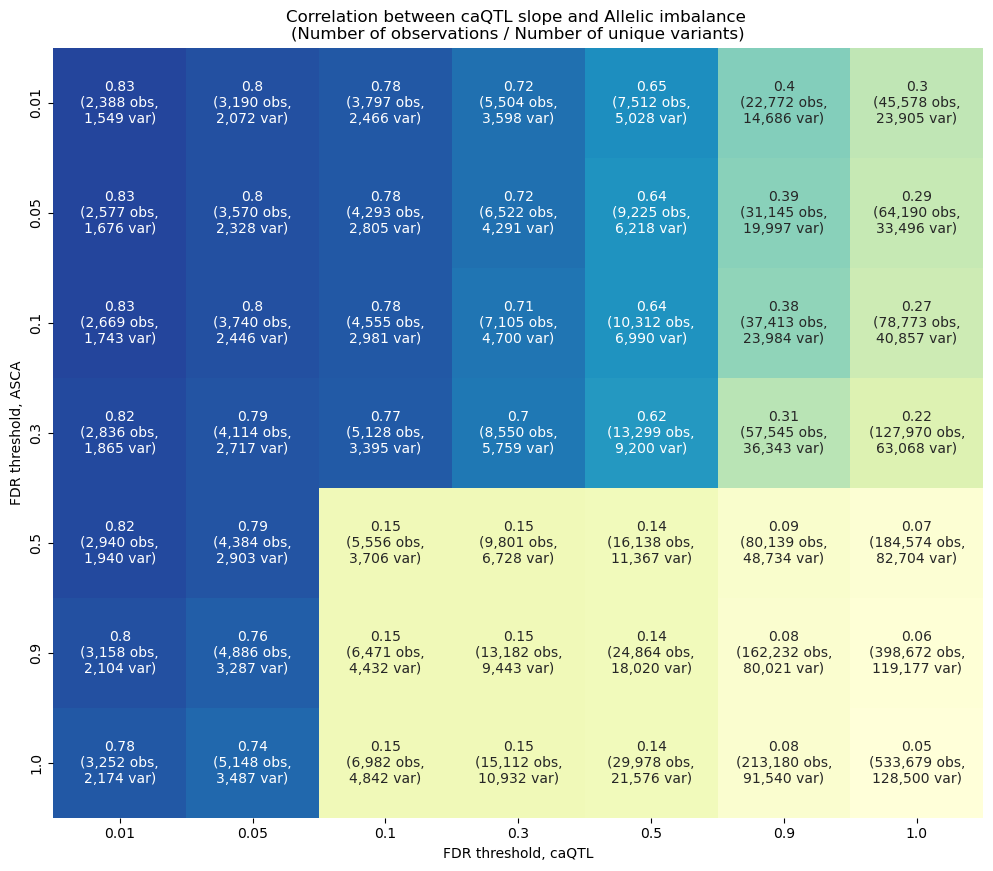

In [18]:
for variant_type in ["all", "SNP", "Indel"]:

    print(f"{variant_type}")
    tmp = df_coherence[df_coherence.variant_type == variant_type]
    print("Coherence between caQTL and Allelic imbalance")
    p = plot_power_heatmap(tmp, title = f"Share of coherent variants between caQTL and Allelic imbalance \n(Number of observations / Number of unique variants)")
    outf_name = f"{outdir}/suppl/FigureS3_heatmap_coherence_caQTL_ASCA_{variant_type}.pdf"
    p.savefig(outf_name, bbox_inches='tight')
    p.show()

    print("Correlation between caQTL and Allelic imbalance")
    p = plot_power_heatmap(tmp, val = "correlation", title = f"Correlation between caQTL slope and Allelic imbalance \n(Number of observations / Number of unique variants)")
    print("\n")
    outf_name = f"{outdir}/suppl/FigureS3_heatmap_correlation_caQTL_ASCA_{variant_type}.pdf"
    p.savefig(outf_name, bbox_inches='tight')
    p.show()


# Correlation of caQTL slopes across cell types

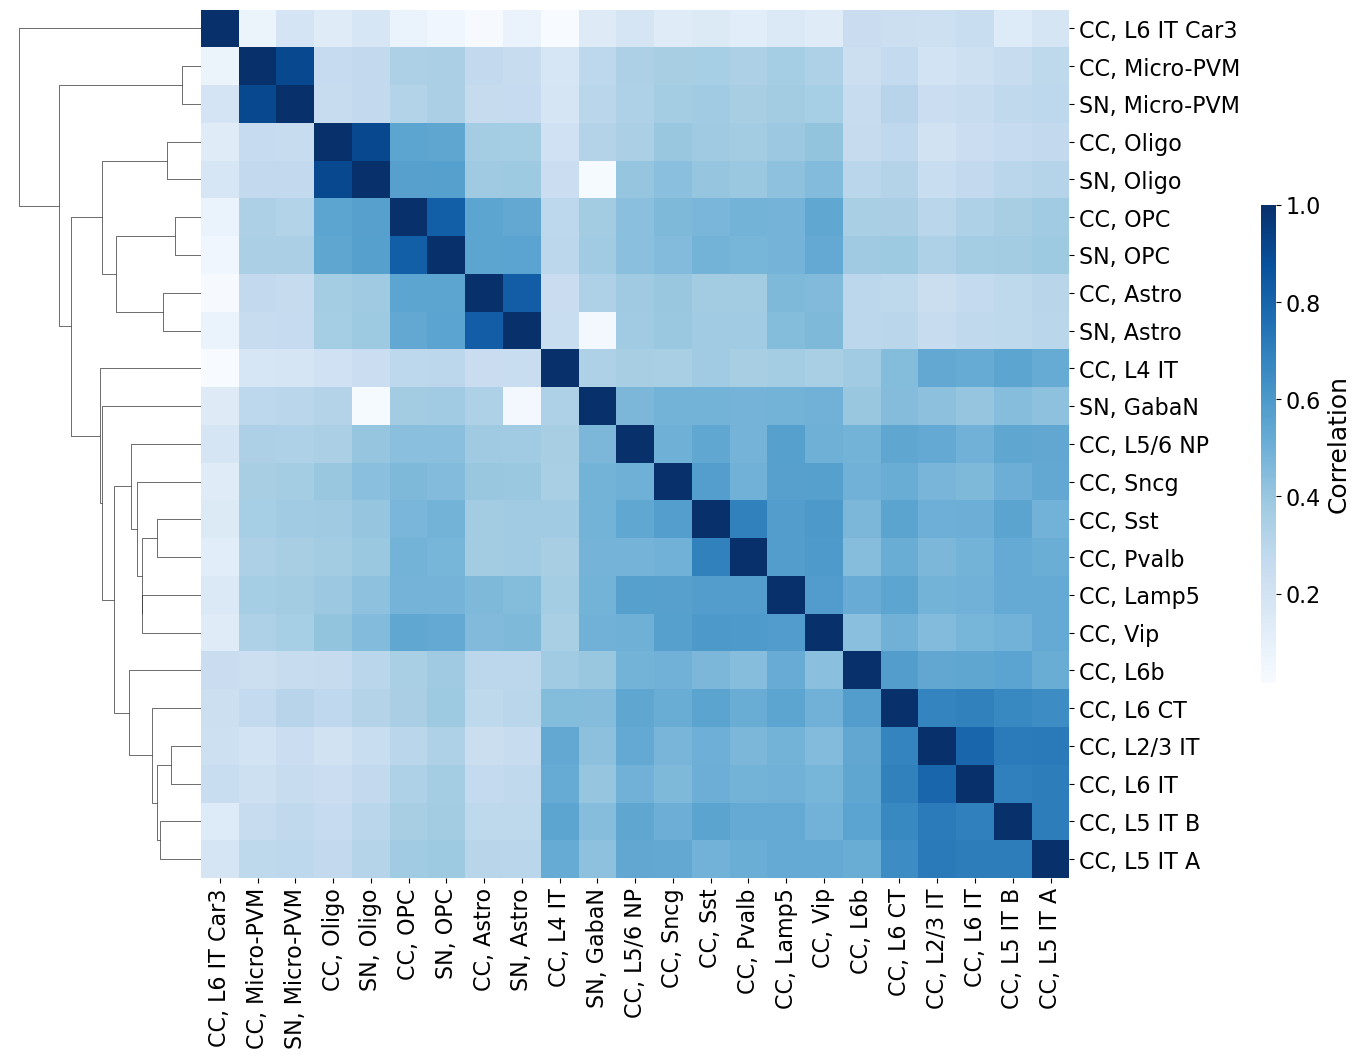

In [4]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Build correlation matrix
# -----------------------------
df_pivot = (
    qtl_asca
    .filter(pl.col("variant_id").is_in(var_list))
    .with_columns(
        (pl.col("brain_region") + ", " + pl.col("cell_type_corrected")).alias("region_ct")
    )
    .pivot("region_ct", index="variant_id", values="slope")
)

corr_df = (
    df_pivot
    .select(pl.exclude("variant_id"))
    .to_pandas()
    .corr(min_periods=500)
)

# -----------------------------
# Clustermap (keep dendrograms)
# -----------------------------
g = sns.clustermap(
    corr_df.fillna(0),
    cmap="Blues",
    annot=False,                  # no numbers on heatmap
    figsize=(12, 12),
    cbar=True,                    # create colorbar, we'll reposition it after
    cbar_kws={"label": "Correlation"},
    dendrogram_ratio=(0.18, 0.18) # keep dendrograms visible
)

# -----------------------------
# Reposition colorbar manually (thin, non-overlapping)
# -----------------------------
# Get heatmap position in figure coordinates
hm_pos = g.ax_heatmap.get_position()

# Put colorbar just to the RIGHT of the heatmap+labels region.
# Tune these values if needed:
pad = 0.025     # gap between heatmap and colorbar
cbar_w = 0.012  # thin colorbar width
cbar_h_frac = 0.55  # fraction of heatmap height used by colorbar

cbar_h = hm_pos.height * cbar_h_frac
cbar_y = hm_pos.y0 + (hm_pos.height - cbar_h) / 2
cbar_x = hm_pos.x1 + pad

if g.cax is not None:
    g.cax.set_position([cbar_x, cbar_y, cbar_w, cbar_h])  # [x, y, w, h]
    g.cax.set_visible(True)
    g.cax.tick_params(labelsize=9)
    g.cax.set_ylabel("Correlation", fontsize=11)

# Hide row dendrogram
g.ax_col_dendrogram.set_visible(False)

# Optional cleanup
g.ax_heatmap.tick_params(axis="x", labelsize=16, rotation=90)
g.ax_heatmap.tick_params(axis="y", labelsize=16)


# move colorbar farther right (after hm_pos is defined)
pad = 0.16   # was 0.025; increase until it clears the row-label text
cbar_x = hm_pos.x1 + pad

if g.cax is not None:
    g.cax.set_position([cbar_x, cbar_y, cbar_w, cbar_h])
    g.cax.tick_params(labelsize=16)   
    g.cax.set_ylabel("Correlation", fontsize=18)

plt.show()

# Optional save
# g.fig.savefig("corr_clustermap.pdf", bbox_inches="tight", dpi=300)


In [5]:
# Save the clustermap to PDF
g.fig.savefig(f"{outdir}/suppl/FigS3_cell_type_corr_caQTL_no_num.pdf", format="pdf", bbox_inches="tight")

# Broad caQTL cell types

In [7]:
variant_types = ["SNP", "Indel"]
cts =["ExN", "InN", "neuron"] 
brain_regions = ["SN", "CC"]

qtl_paths = {
             "CC": "/lustre1/project/stg_00090/ASA/analysis/2024_T2T_ATAC_analysis/CC/deeplearning/tensorQTL/out/parquets_250513/broad_celltypes/CT2_peak_regions/genotype_data_pca_30/",
             "SN": "/lustre1/project/stg_00090/ASA/analysis/2024_T2T_ATAC_analysis/SN/deeplearning/tensorQTL/out/parquets_250513/CT2_peak_regions/genotype_data_pca_30/"
            }

qtl_list = []

for brain_region in brain_regions:

    for variant_type in variant_types:

        # all files for the brain region
        # version with PD/CN as covariate
        # qtl_dir = f"{analysis_dir}/{brain_region}/deeplearning/tensorQTL/out/parquets_250303/CT2_peak_regions/genotype_data_pca_30"
        # final version
        qtl_dir = qtl_paths[brain_region]
        qtl_files = glob.glob(f"{qtl_dir}/*_{variant_type}*.parquet")

        # extract cell types
        cell_types = set([os.path.basename(file).split(f"_{variant_type}")[0] for file in qtl_files])
        print(cell_types)

        # extraact chromosome name 
        chromosomes = set([os.path.basename(file).split("qtl_pairs.")[1].split(".parquet")[0] for file in qtl_files])
        print(chromosomes)

        for cell_type in cell_types:
            if cell_type in cts:
                print(f"Processing {brain_region}, {cell_type}, {variant_type}...")

                for chromosome in chromosomes:

                    qtl_path = f"{qtl_dir}/{cell_type}_{variant_type}.cis_qtl_pairs.{chromosome}.parquet"
                    qtl = pl.read_parquet(qtl_path)
                    qtl = qtl.with_columns(
                        pl.lit(cell_type).alias("cell_type"),
                        pl.lit(variant_type).alias("variant_type"),
                        pl.lit(brain_region).alias("brain_region"),
                        pl.lit(chromosome).alias("chr")
                    )
                    qtl_list.append(qtl)
                
            else:
                continue
                

qtl = pl.concat(qtl_list)      

{'Oligo', 'Astro', 'Micro-PVM', 'OPC', 'DopaN', 'neuron', 'GabaN', 'Endo'}
{'chr2', 'chr1', 'chr10', 'chr9', 'chr12', 'chr7', 'chr22', 'chr5', 'chr13', 'chr11', 'chr3', 'chr16', 'chr14', 'chr18', 'chr20', 'chr19', 'chr6', 'chr17', 'chr4', 'chr8', 'chr15', 'chr21'}
Processing SN, neuron, SNP...
{'Oligo', 'Astro', 'OPC', 'DopaN', 'neuron', 'Micro-PVM', 'GabaN', 'Endo'}
{'chr2', 'chr1', 'chr10', 'chr9', 'chr12', 'chr22', 'chr7', 'chr5', 'chr13', 'chr11', 'chr3', 'chr16', 'chr14', 'chr20', 'chr18', 'chr19', 'chr6', 'chr17', 'chr4', 'chr8', 'chr15', 'chr21'}
Processing SN, neuron, Indel...
{'Oligo', 'Astro', 'OPC', 'ExN', 'Micro-PVM', 'InN'}
{'chr2', 'chr1', 'chr10', 'chr9', 'chr12', 'chr22', 'chr7', 'chr5', 'chr13', 'chr11', 'chr3', 'chr16', 'chr14', 'chr18', 'chr20', 'chr19', 'chr6', 'chr17', 'chr4', 'chr8', 'chr15', 'chr21'}
Processing CC, ExN, SNP...
Processing CC, InN, SNP...
{'Oligo', 'Astro', 'OPC', 'ExN', 'Micro-PVM', 'InN'}
{'chr2', 'chr1', 'chr10', 'chr9', 'chr12', 'chr22', 'chr7'

In [11]:
# keep variants that overlap peaks (relevant for indels and SVs)
qtl= qtl.filter(((pl.col("start_distance") >= 0) & (pl.col("start_distance") < 500)) |  # variants with start within the peak
                     ((pl.col("end_distance") > -500) & (pl.col("end_distance") <= 0)) | # variants with end within the peak
                     ((pl.col("start_distance") < 0) & (pl.col("end_distance") > 0))) # variants that span the peak

# remove missing
qtl = qtl.drop_nulls()

In [12]:
# adjuted p-values - full set (all variants and cell types, incl indels and SVs)
p_values = qtl["pval_nominal"].to_list()
signif, p_adj = statsmodels.stats.multitest.fdrcorrection(p_values, alpha=0.05, is_sorted=False)
qtl = qtl.with_columns(pl.Series("caQTL_broad_pval_adj", p_adj))

In [13]:
# corrected cell type names
qtl = qtl.with_columns(
            pl.col("cell_type").replace("neuron", "SN, neurons").replace("ExN", "CC, excitatory neurons").replace("InN", "CC, inhibitory neurons").alias("cell_type_label")
        )

In [15]:
qtl.write_csv(f"{data_dir}/caQTL_broad_cell_types.csv.gz") 

In [10]:
qtl.filter(pl.col("pval_nominal") < 0.001)["variant_id"].n_unique(), qtl.filter(pl.col("caQTL_broad_pval_adj") < 0.1)["variant_id"].n_unique()

(51194, 41686)

In [48]:
# load full caQTL results (before aggregatng with ASCA and removing non-quantified ones)
# outdir = f"{analysis_dir}/2024_T2T_ATAC_analysis//20250513_caQTL_pop_PCA_combined"
# qtl_full = pl.read_parquet(f"{outdir}/tensorQTL_results.parquet")

In [17]:
celltype_to_broad = {
    # Excitatory neurons (Glutamatergic) -> ExN
    "L23_IT": "ExN",
    "L4_IT": "ExN",
    "L5_IT_A": "ExN",
    "L5_IT_B": "ExN",
    "L5_ET": "ExN",
    "L56_NP": "ExN",
    "L6_IT": "ExN",
    "L6_IT_Car3": "ExN",
    "L6_CT": "ExN",
    "L6b": "ExN",

    # Inhibitory neurons (GABAergic) -> InN
    "Sst": "InN",
    "Vip": "InN",
    "Pvalb": "InN",
    "Lamp5": "InN",
    "Sncg": "InN",
    "GabaN": "InN",

    # SN neurons -> neuron (your broad catch-all neuronal bin)
    "DopaN": "neuron",
    'GabaN': "neuron"
}

# qtl_full = qtl_full.with_columns(
#     pl.col("cell_type").replace(celltype_to_broad).alias("broad_cell_type")
# )  

qtl_asca_filt = qtl_asca_filt.with_columns(
    pl.col("cell_type").replace(celltype_to_broad).alias("broad_cell_type")
)  

In [20]:
qtl_asca_filt["broad_cell_type"].unique().to_list()

['ExN', 'Micro-PVM', 'Oligo', 'neuron', 'InN', 'OPC', 'Astro']

In [21]:
qtl_filt = qtl.filter(pl.col("caQTL_broad_pval_adj") < 0.1)

# df_comb = qtl_filt.join(qtl_full.filter(pl.col("cell_type") != "neuron", pl.col("pval_nominal") < 0.001), left_on=["variant_id", "cell_type"], right_on = ["variant_id", "broad_cell_type"])

df_comb = qtl_filt.join(qtl_asca_filt, left_on=["variant_id", "cell_type"], right_on = ["variant_id", "broad_cell_type"])

#df_comb = qtl_filt.join(qtl_asca_filt, left_on=["variant_id", "brain_region"], right_on = ["variant_id", "brain_region"])
df_comb 

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,cell_type,variant_type,brain_region,chr,caQTL_broad_pval_adj,cell_type_label,variant_type_right,peak_id,brain_region_right,cell_type_right,diff,logfc,max_percentile,model,start_distance_right,end_distance_right,af_right,ma_samples_right,ma_count_right,pval_nominal_right,slope_right,slope_se_right,chr_right,caQTL_pval_adj_full,TEST.SNP.CHROM,TEST.SNP.POS,TEST.SNP.REF.ALLELE,…,REGION.END,LOGLIKE.NULL,LOGLIKE.ALT,CHISQ,P.VALUE,ALPHA,BETA,PHI,TOTAL.AS.READ.COUNT,REF.AS.READ.COUNT,ALT.AS.READ.COUNT,TOTAL.READ.COUNT,REF_LEN,ALT_LEN,allelic_imbalance,MAX_ALLELE_LEN,pval_adj,signif_fdr05,indel_bin,signif,pval_adj_full,signif_fdr05_full,ASCA_pval_adj_full,asca_fdr_bin,qtl_fdr_bin,abs_allelic_imbalance,abs_slope,allelic_imbalance_0.1,slope_0.1,effect_size_filt,signif_ASCA,signif_caQTL,signif_caQTL_ASCA,signif_caQTL_or_ASCA,signif_caQTL_or_ASCA_fdr001,signif_caQTL_ASCA_no_effect_size_filter,cell_type_corrected
str,str,i32,i32,f32,i32,i32,f64,f32,f32,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,i64,i64,f64,i64,i64,f64,f64,f64,str,f64,str,i64,str,…,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,bool,str,str,f64,bool,f64,str,str,f64,f64,bool,bool,bool,bool,bool,bool,bool,bool,bool,str
"""chr12:117020828-117021328""","""chr12_117021068_G_A""",239,-260,0.134831,44,48,5.1430e-13,-0.319916,0.03998,"""ExN""","""SNP""","""CC""","""chr12""",1.3932e-9,"""CC, excitatory neurons""","""SNP""","""chr12:117020828-117021328""","""CC""","""L23_IT""",-1.033747,-1.004153,99.98325,"""cc_deepPeak_mean_finetuned""",239,-260,0.128049,39,42,8.6430e-9,-0.315124,0.050902,"""chr12""",0.000005,"""chr12""",117021068,"""G""",…,117021328,-399.2,-374.45,49.508,1.9753e-12,0.673489,0.213403,0.001175,735,575,160,0,1,1,-0.259381,1,3.5500e-10,true,"""SNP""","""pval < e-5""",3.6433e-10,true,4.0406e-10,"""<0.01""","""<0.01""",0.259381,0.315124,true,true,true,true,true,true,true,true,true,"""L2/3 IT"""
"""chr9:123123468-123123968""","""chr9_123123707_C_T""",238,-261,0.103933,36,37,3.5569e-13,-0.376386,0.046646,"""ExN""","""SNP""","""CC""","""chr9""",9.9377e-10,"""CC, excitatory neurons""","""SNP""","""chr9:123123468-123123968""","""CC""","""L23_IT""",-1.005486,-2.163187,99.8635,"""cc_deepPeak_mean_finetuned""",238,-261,0.106707,34,35,2.5303e-11,-0.403461,0.054829,"""chr9""",2.7084e-8,"""chr9""",123123707,"""C""",…,123123968,-119.01,-58.0,122.03,0.0,0.762345,0.0352836,0.00123,447,433,14,0,1,1,-0.455764,1,0.0,true,"""SNP""","""pval < e-5""",0.0,true,0.0,"""<0.01""","""<0.01""",0.455764,0.403461,true,true,true,true,true,true,true,true,true,"""L2/3 IT"""
"""chr11:132164777-132165277""","""chr11_132165055_G_T""",277,-222,0.036517,13,13,0.000193,-0.272828,0.071146,"""ExN""","""SNP""","""CC""","""chr11""",0.046687,"""CC, excitatory neurons""","""SNP""","""chr11:132164777-132165277""","""CC""","""L23_IT""",-0.8946,-1.827499,99.84625,"""cc_deepPeak_mean_finetuned""",277,-222,0.039634,13,13,0.000028,-0.443588,0.101822,"""chr11""",0.005606,"""chr11""",132165055,"""G""",…,132165277,-62.22,-54.0,16.453,0.00005,0.72059,0.139781,0.001194,155,139,16,0,1,1,-0.337534,1,0.002175,true,"""SNP""","""pval > e-5""",0.002225,true,0.002442,"""<0.01""","""<0.01""",0.337534,0.443588,true,true,true,true,true,true,true,true,true,"""L2/3 IT"""
"""chr12:117020828-117021328""","""chr12_117021068_G_A""",239,-260,0.134831,44,48,5.1430e-13,-0.319916,0.03998,"""ExN""","""SNP""","""CC""","""chr12""",1.3932e-9,"""CC, excitatory neurons""","""SNP""","""chr12:117020828-117021328""","""CC""","""L5_IT_A""",-0.875948,-1.04591,99.977,"""cc_deepPeak_mean_finetuned""",239,-260,0.109489,28,30,0.001229,-0.412075,0.123586,"""chr12""",0.099725,"""chr12""",117021068,"""G""",…,117021328,-40.85,-36.76,8.172,0.004254,0.660976,0.233404,0.0011559,74,53,21,0,1,1,-0.239033,1,0.085701,false,"""SNP""","""pval > e-5""",0.071238,false,0.076872,"""0.01-0.1""","""0.01-0.1""",0.239033,0.4120753,true,true,true,

In [22]:
pl.Config(tbl_rows=20)
# correlation per group
df_cor = df_comb.group_by(
            "cell_type", "cell_type_corrected"
        ).agg(
            pl.corr("slope", "slope_right").alias("correlation"),
            pl.len().alias("n_obs")
        ).sort(
            "cell_type"
        ).with_columns(
            pl.col("cell_type").replace("neuron", "SN, neurons").replace("ExN", "CC, excitatory neurons").replace("InN", "CC, inhibitory neurons")
        )

cor_wide = df_cor.pivot(
    index="cell_type_corrected", 
    columns="cell_type", 
    values="correlation"
)
cor_wide 


/tmp/ipykernel_3699732/1091026549.py:14: DeprecationWarning: The argument `columns` for `DataFrame.pivot` is deprecated. It has been renamed to `on`.


cell_type_corrected,"CC, excitatory neurons","CC, inhibitory neurons","SN, neurons"
str,f64,f64,f64
"""L6 CT""",0.900839,null,null
"""L4 IT""",0.888879,null,null
"""L6b""",0.894511,null,null
"""L5 IT B""",0.937305,null,null
"""L5/6 NP""",0.897159,null,null
"""L6 IT""",0.958137,null,null
"""L2/3 IT""",0.976939,null,null
"""L5 IT A""",0.940328,null,null
"""Sst""",null,0.961611,null


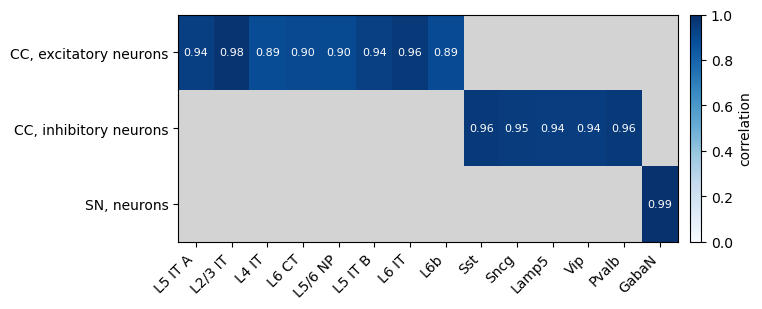

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# cor_wide: Polars DataFrame
# first col = row labels; remaining cols = numeric correlations
row_col = "cell_type_corrected"
value_cols = [c for c in cor_wide.columns if c != row_col]

# ---- Build matrix and transpose ----
row_labels = cor_wide[row_col].to_list()   # will become x-axis after transpose
col_labels = value_cols                    # will become y-axis after transpose

mat = cor_wide.select(value_cols).to_numpy().T  # transpose here

# ---- Plot ----
fig, ax = plt.subplots(figsize=(max(8, len(row_labels) * 0.55), 3.2))

cmap = plt.cm.Blues.copy()
cmap.set_bad(color="lightgrey")  # missing values as grey

masked = np.ma.masked_invalid(mat)
im = ax.imshow(
    masked,
    aspect="auto",
    interpolation="nearest",
    cmap=cmap,
    vmin=0,   # range 0 to 1
    vmax=1
)

# ticks
ax.set_xticks(np.arange(len(row_labels)))
ax.set_xticklabels(row_labels, rotation=45, ha="right")
ax.set_yticks(np.arange(len(col_labels)))
ax.set_yticklabels(col_labels)

# no axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# annotate non-missing values
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat[i, j]
        if not np.isnan(val):
            # darker text for light blues near low values, white for high values
            txt_color = "white" if val > 0.65 else "black"
            # change the annotation line to:
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=txt_color)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("correlation")

plt.tight_layout()
outf_name = f"{outdir}/suppl/FigureS3_heatmap_correlation_caQTL_broad_cell_types.pdf"
plt.savefig(outf_name, bbox_inches='tight')
plt.show()

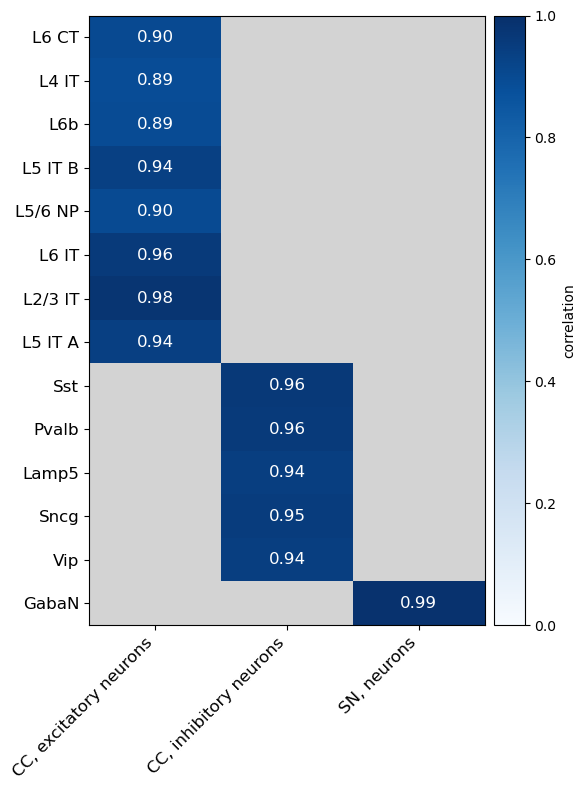

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# cor_wide: Polars DataFrame
# first col = row labels; remaining cols = numeric correlations
row_col = "cell_type_corrected"
value_cols = [c for c in cor_wide.columns if c != row_col]

# ---- Build matrix (NO transpose) ----
row_labels = cor_wide[row_col].to_list()   # rows (y-axis)
col_labels = value_cols                    # columns (x-axis)

mat = cor_wide.select(value_cols).to_numpy()  # <- removed .T

# ---- Plot ----
#fig, ax = plt.subplots(figsize=(max(8, len(col_labels) * 0.45), max(3.2, len(row_labels) * 0.45)))
fig, ax = plt.subplots(figsize=(6,8))

cmap = plt.cm.Blues.copy()
cmap.set_bad(color="lightgrey")  # missing values as grey

masked = np.ma.masked_invalid(mat)
im = ax.imshow(
    masked,
    aspect="auto",
    interpolation="nearest",
    cmap=cmap,
    vmin=0,   # range 0 to 1
    vmax=1
)

# ticks
ax.set_xticks(np.arange(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=12)
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=12)

# no axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# annotate non-missing values
for i in range(mat.shape[0]):      # rows
    for j in range(mat.shape[1]):  # cols
        val = mat[i, j]
        if not np.isnan(val):
            txt_color = "white" if val > 0.65 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=12, color=txt_color)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("correlation")

plt.tight_layout()
outf_name = f"{outdir}/suppl/FigureS3_heatmap_correlation_caQTL_broad_cell_types.pdf"
#plt.savefig(outf_name, bbox_inches="tight")
plt.savefig(
    outf_name,
    bbox_inches="tight",
    dpi=600,                 # high resolution for rasterized heatmap
    facecolor="white",       # or your desired background
    edgecolor="none",
    transparent=False
)
plt.show()